In [1]:
import os
import itertools
import numpy as np
import math
import matplotlib.pyplot as plt
import time


# Chọn bản đồ + hàm trực quan bản đồ

In [2]:
# ===== Nạp bản đồ =====
# Ưu tiên dùng file local của bạn, sau đó fallback sang file cùng thư mục notebook hoặc /mnt/data.
grid30 = np.loadtxt('E:\last_dance\Last-dance\map\grid30.txt', dtype=np.int8)

# ===== Khai báo waypoint bắt buộc =====
# Các ô trong danh sách goals sẽ được đánh dấu bằng giá trị 2 trên grid.
goals = [(4, 6), (4, 15), (16, 4), (12, 14), (20, 20), (20, 14), (23, 17), (17, 15)]
# goals = [(4, 6), (12, 14), (18, 10)]
#goals = [(46, 46), (6, 18), (23, 37), (6, 48), (24, 6), (34, 20), (28, 46), (16, 13), (38, 44), (45, 34)]


for goal in goals:
    grid30[goal] = 2

grid = grid30
n = grid.shape[0]


In [3]:
import matplotlib.pyplot as plt
import numpy as np
def visualize_path(grid, path, mandatory_waypoints):
    if path:
        print("\nĐường đi được trích xuất:")
        print(path)
        L_q = path_length(path)
        print("Độ dài đường đi:", round(L_q, 3))

        # Trực quan hóa đường đi Q-Learning
        print("\nĐang trực quan hóa đường đi Q-Learning...")
        fig, ax = plt.subplots(figsize=(8, 8))

        # Vẽ bản đồ (0=free, 1=obstacle)
        # Sử dụng origin="upper" để đặt (0,0) ở góc trên bên trái
        im = ax.imshow(grid, origin="upper", interpolation="nearest", cmap="viridis")

        # Vẽ đường đi theo từng bước
        xs = [p[1] for p in path] # Hoán đổi x và y để vẽ
        ys = [p[0] for p in path] # Hoán đổi x và y để vẽ
        ax.plot(xs, ys, linewidth=2, color="red", zorder=3) # Sử dụng màu khác cho đường đi Q
        ax.scatter([path[0][1], path[-1][1]], # Hoán đổi x và y để vẽ
                [path[0][0], path[-1][0]], # Hoán đổi x và y để vẽ
                marker='x', s=160, linewidths=2.5, color="red", zorder=4)

        # Vẽ các điểm bắt buộc
        mandatory_wp_x = [wp[1] for wp in mandatory_waypoints]
        mandatory_wp_y = [wp[0] for wp in mandatory_waypoints]
        ax.scatter(mandatory_wp_x, mandatory_wp_y, marker='o', s=100, linewidths=2.5, color="blue", zorder=5, label="Điểm bắt buộc")

        # ======= THÊM LƯỚI Ô NGUYÊN  =======
        n, m = grid.shape
        ax.set_xlim(-0.5, m - 0.5) # Điều chỉnh giới hạn dựa trên lưới không xoay
        ax.set_ylim(n - 0.5, -0.5) # Điều chỉnh giới hạn và đảo ngược cho origin="upper"
        ax.set_aspect('equal')
        ax.set_xticks(np.arange(-0.5, m, 1), minor=False) # Điều chỉnh vạch đánh dấu
        ax.set_yticks(np.arange(-0.5, n, 1), minor=False) # Điều chỉnh vạch đánh dấu
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        ax.grid(which='major', linestyle='-', linewidth=0.6, alpha=0.6, color='white')

        ax.set_title(f"Đường đi có độ dài={L_q:.2f}, số bước={len(path)-1}")
        ax.legend()

        plt.tight_layout()
        # out_path_q = "/mnt/data/q_learning_path.png"
        # plt.savefig(out_path_q, dpi=180)
        plt.show() # Hiển thị biểu đồ đường đi Q-Learning
        # plt.close(fig)
        # print("\nĐã lưu trực quan hóa đường đi Q-Learning vào:", out_path_q)

    else:
        print("\nKhông thể trích xuất đường đi hợp lệ từ bảng Q.")

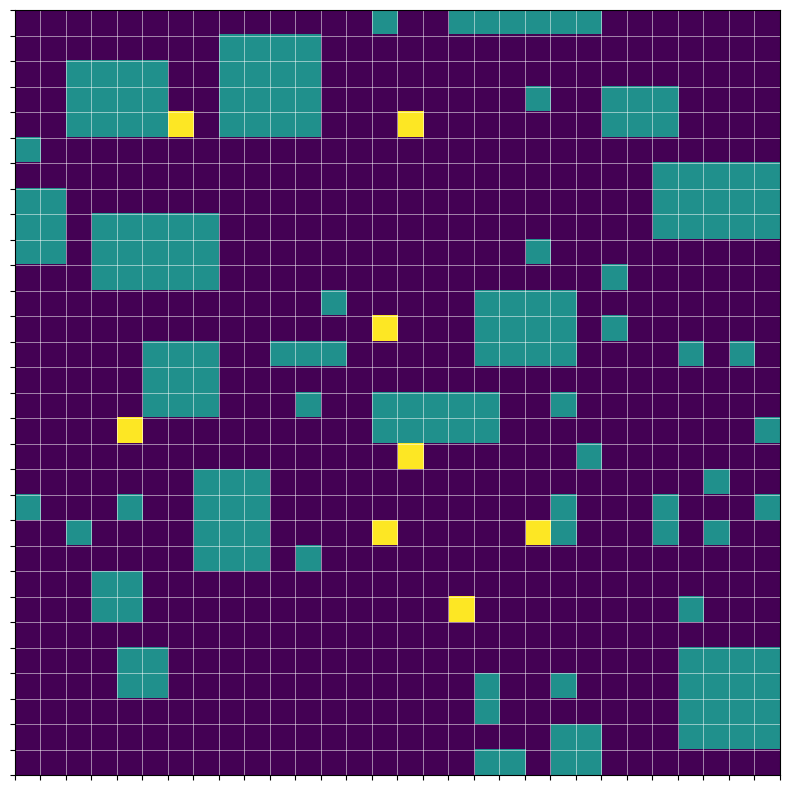

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Trực quan hóa đường đi Q-Learning
fig, ax = plt.subplots(figsize=(8, 8))

# Vẽ bản đồ (0=free, 1=obstacle)
# Sử dụng origin="upper" để đặt (0,0) ở góc trên bên trái
im = ax.imshow(grid, origin="upper", interpolation="nearest", cmap="viridis")

# ======= THÊM LƯỚI Ô NGUYÊN  =======
n, m = grid.shape
ax.set_xlim(-0.5, m - 0.5) # Điều chỉnh giới hạn dựa trên lưới không xoay
ax.set_ylim(n - 0.5, -0.5) # Điều chỉnh giới hạn và đảo ngược cho origin="upper"
ax.set_aspect('equal')
ax.set_xticks(np.arange(-0.5, m, 1), minor=False) # Điều chỉnh vạch đánh dấu
ax.set_yticks(np.arange(-0.5, n, 1), minor=False) # Điều chỉnh vạch đánh dấu
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.grid(which='major', linestyle='-', linewidth=0.6, alpha=0.6, color='white')


plt.tight_layout()
# out_path_q = "/mnt/data/q_learning_path.png"
# plt.savefig(out_path_q, dpi=180)
plt.show() # Hiển thị biểu đồ đường đi Q-Learning
# plt.close(fig)
# print("\nĐã lưu trực quan hóa đường đi Q-Learning vào:", out_path_q)

# Các hàm phụ trợ

In [5]:
# Kiểm tra điểm có nằm trong lưới không
def in_bounds(p, n, m):
    return 0 <= p[0] < n and 0 <= p[1] < m

# ---------- helpers ----------
MOVES8 = [(-1,-1), (-1,0), (-1,1),
          ( 0,-1),          ( 0,1),
          ( 1,-1), ( 1,0),  ( 1,1)]

# Hàm khoảng cách Euclid giữa hai điểm
def euclid(a, b):
    return math.hypot(a[0] - b[0], a[1] - b[1])

# Tính độ dài đường đi
def path_length(path):
    if not path or len(path) < 2:
        return 0.0
    return sum(euclid(path[i], path[i + 1]) for i in range(len(path) - 1))

In [6]:
# Tạo sub_grid từ start_point đến end_point
def create_sub_grid(start_point, end_point, grid):
    x_min = min(start_point[0], end_point[0])
    x_max = max(start_point[0], end_point[0])
    y_min = min(start_point[1], end_point[1])
    y_max = max(start_point[1], end_point[1])
    
    return grid[x_min:x_max+1, y_min:y_max+1]

In [7]:
# Tạo sub_grid từ start_point đến end_point bổ sung padding 1 ô xung quanh để tránh lỗi index khi đi chéo
def create_sub_grid_with_padding(start_point, end_point, grid, padding):
    x_min = min(start_point[0], end_point[0])
    x_max = max(start_point[0], end_point[0])
    y_min = min(start_point[1], end_point[1])
    y_max = max(start_point[1], end_point[1])
    
    return grid[x_min-padding:x_max+1+padding, y_min-padding:y_max+1+padding]

In [8]:
#test create_sub_grid
start_point = (4, 6)
end_point = (12, 14)
sub_grid = create_sub_grid(start_point, end_point, grid)
print("Sub-grid:")
print(sub_grid)

Sub-grid:
[[2 0 1 1 1 1 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [1 1 0 0 0 0 0 0 0]
 [1 1 0 0 0 0 0 0 0]
 [1 1 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 0 0 2]]


In [9]:
#test create_sub_grid_with_padding
start_point = (4, 6)
end_point = (12, 14)
padding = 1
sub_grid = create_sub_grid_with_padding(start_point, end_point, grid, padding)
print("Sub-grid với padding:")
print(sub_grid)

Sub-grid với padding:
[[1 0 0 1 1 1 1 0 0 0 0]
 [1 2 0 1 1 1 1 0 0 0 2]
 [0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0]
 [1 1 1 0 0 0 0 0 0 0 0]
 [1 1 1 0 0 0 0 0 0 0 0]
 [1 1 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 1 0 0 0]
 [0 0 0 0 0 0 0 0 0 2 0]
 [1 1 1 0 0 1 1 1 0 0 0]]


# Dijkstra + vét cạn toàn bộ thứ tự waypoint


In [10]:
# Tìm đường đi ngắn nhất từ start_point đến end_point chỉ đi xuống và sang phải (có thể đi chéo phải)
def find_path_segment_down_right(start_point, end_point, grid):
    sub_grid = create_sub_grid(start_point, end_point, grid)
    n, m = sub_grid.shape

    # B1: tính ma trận khoảng cách d
    d = np.full((n, m), fill_value=1e10, dtype=np.float64)
    d[0][0] = 0

    for i in range(1, n):
        if sub_grid[i][0] != 1:
            d[i][0] = min(d[i][0], d[i-1][0] + 1)

    for j in range(1, m):
        if sub_grid[0][j] != 1:
            d[0][j] = min(d[0][j], d[0][j-1] + 1)

    for i in range(1, n):
        for j in range(1, m):
            if sub_grid[i][j] != 1:
                d[i][j] = min(
                    d[i][j],
                    d[i-1][j] + 1,          # đi xuống
                    d[i][j-1] + 1,          # đi sang phải
                    d[i-1][j-1] + math.sqrt(2)  # đi chéo
                )

    print("Độ dài đường đi ngắn nhất tới đích:", d[n-1][m-1])

    # B2: truy vết đường đi từ (n-1, m-1) về (0,0)
    path = []
    i, j = n-1, m-1

    if d[i, j] > 1e9:
        print("Không có đường đi hợp lệ tới đích")
        return [], 1e10
    else:
        while not (i == 0 and j == 0):
            path.append((i, j))
            found = False
            # Thử lần lượt: chéo, lên, trái (ưu tiên chéo cho đẹp)
            for di, dj, cost in [(-1, -1, math.sqrt(2)), (-1, 0, 1), (0, -1, 1)]:
                pi, pj = i + di, j + dj
                if pi < 0 or pj < 0:
                    continue
                # kiểm tra xem (pi,pj) có thể là cha của (i,j) không
                if abs(d[i, j] - (d[pi, pj] + cost)) < 1e-6:
                    i, j = pi, pj
                    found = True
                    break
            if not found:
                raise RuntimeError(f"Backtrack bị kẹt tại ô {(i, j)}")

        path.append((0, 0))
        path.reverse()
        # Cộng thêm offset để chuyển từ sub_grid về grid gốc
        offset_x = min(start_point[0], end_point[0])
        offset_y = min(start_point[1], end_point[1])
        path = [(x + offset_x, y + offset_y) for x, y in path]

        return path, d[n-1][m-1]

In [11]:
def find_path_segment_down_left(start_point, end_point, grid):
    sub_grid = create_sub_grid(start_point, end_point, grid)
    n, m = sub_grid.shape

    # B1: tính ma trận khoảng cách d
    d = np.full((n, m), fill_value=1e10, dtype=np.float64)
    d[0][m-1] = 0

    for i in range(1, n):
        if sub_grid[i][m-1] != 1:
            d[i][m-1] = min(d[i][m-1], d[i-1][m-1] + 1)

    for j in range(m-2, -1, -1):
        if sub_grid[0][j] != 1:
            d[0][j] = min(d[0][j], d[0][j+1] + 1)

    for i in range(1, n):
        for j in range(m-2, -1, -1):
            if sub_grid[i][j] != 1:
                d[i][j] = min(
                    d[i][j],
                    d[i-1][j] + 1,          # đi xuống
                    d[i][j+1] + 1,          # đi sang trái
                    d[i-1][j+1] + math.sqrt(2)  # đi chéo
                )

    print("Độ dài đường đi ngắn nhất tới đích:", d[n-1][0])

    # B2: truy vết đường đi từ (n-1, 0) về (0,m-1)
    path = []
    i, j = n-1, 0

    if d[i, j] > 1e9:
        print("Không có đường đi hợp lệ tới đích")
        return [], 1e10
    else:
        while not (i == 0 and j == m-1):
            path.append((i, j))
            found = False
            # Thử lần lượt: chéo, lên, phải (ưu tiên chéo cho đẹp)
            for di, dj, cost in [(-1, 1, math.sqrt(2)), (-1, 0, 1), (0, 1, 1)]:
                pi, pj = i + di, j + dj
                if pi < 0 or pj >= m:
                    continue
                # kiểm tra xem (pi,pj) có thể là cha của (i,j) không
                if abs(d[i, j] - (d[pi, pj] + cost)) < 1e-6:
                    i, j = pi, pj
                    found = True
                    break
            if not found:
                raise RuntimeError(f"Backtrack bị kẹt tại ô {(i, j)}")

        path.append((0, m-1))
        path.reverse()
        # Cộng thêm offset để chuyển từ sub_grid về grid gốc
        offset_x = min(start_point[0], end_point[0])
        offset_y = min(start_point[1], end_point[1])
        path = [(x + offset_x, y + offset_y) for x, y in path]
        return path, d[n-1][0]

In [12]:
import heapq

# Hàm tìm đường đi ngắn nhất giữa hai điểm (start_point) và (end_point) sử dụng Dijkstra
# Với khả năng di chuyển 8 hướng và tránh chướng ngại vật (giá trị 1)
# Độ phức tạp: O(n*m*log(n*m)) trong trường hợp xấu nhất, với n và m là số hàng và số cột của lưới
def dijkstra(grid_map, start_point, end_point):
    n_rows, n_cols = grid_map.shape

    # Kiểm tra điểm bắt đầu và kết thúc có hợp lệ không
    if not in_bounds(start_point, n_rows, n_cols) or grid_map[start_point[0]][start_point[1]] == 1:
        print(f"Điểm bắt đầu {start_point} không hợp lệ hoặc là chướng ngại vật.")
        return [], 1e10 # Trả về đường đi rỗng và độ dài vô cùng lớn nếu điểm bắt đầu không hợp lệ
    if not in_bounds(end_point, n_rows, n_cols) or grid_map[end_point[0]][end_point[1]] == 1:
        print(f"Điểm kết thúc {end_point} không hợp lệ hoặc là chướng ngại vật.")
        return [], 1e10

    # distances lưu trữ khoảng cách ngắn nhất từ start_point đến mỗi ô
    # dictionary (row, col) -> min distance giữa start_point và (row, col), kích thước n_rows x n_cols
    distances = { (r, c): 1e10 for r in range(n_rows) for c in range(n_cols) } 
    distances[start_point] = 0

    # predecessors lưu trữ ô trước đó trong đường đi ngắn nhất, dạng dictionary (row, col) -> (prev_row, prev_col)
    predecessors = {}

    # priority_queue (min-heap) để lưu trữ (khoảng_cách, ô_hiện_tại), trong đó khoảng cách là khoảng cách ngắn nhất đã biết từ start_point đến ô_hiện_tại
    priority_queue = [ (0, start_point) ]

    while priority_queue: # Trong khi hàng đợi ưu tiên không rỗng
        current_distance, current_node = heapq.heappop(priority_queue) # Lấy ô có khoảng cách nhỏ nhất từ hàng đợi
        # print(f"Đang xử lý node {current_node} với khoảng cách {current_distance}")
        # print(f"Hàng đợi ưu tiên: {priority_queue}")

        # Nếu đã tìm thấy đường đi ngắn nhất đến current_node rồi, bỏ qua
        if current_distance > distances[current_node]:
            continue

        # Nếu đã đến đích, dừng tìm kiếm
        if current_node == end_point:
            break

        # Duyệt qua 8 ô lân cận
        for dr, dc in MOVES8:
            neighbor_node = (current_node[0] + dr, current_node[1] + dc)

            # Kiểm tra ô lân cận có hợp lệ không (trong biên, không phải chướng ngại vật)
            if in_bounds(neighbor_node, n_rows, n_cols) and grid_map[neighbor_node[0]][neighbor_node[1]] != 1:
                # Tính chi phí di chuyển (1 cho ngang/dọc, sqrt(2) cho chéo)
                move_cost = math.hypot(dr, dc) # math.hypot((dr, dc)) will be 1 or sqrt(2)

                # Tính khoảng cách mới đến ô lân cận
                new_distance = current_distance + move_cost

                # Nếu tìm thấy đường đi ngắn hơn đến ô lân cận
                if new_distance < distances[neighbor_node]:
                    distances[neighbor_node] = new_distance
                    # print(distances)
                    predecessors[neighbor_node] = current_node
                    # print(predecessors)
                    heapq.heappush(priority_queue, (new_distance, neighbor_node))

    # Tái tạo đường đi từ end_point về start_point
    path = []
    if distances[end_point] == 1e10: # Không tìm thấy đường đi
        return [], 1e10

    current = end_point
    while current != start_point:
        path.append(current)
        current = predecessors.get(current)
        if current is None: # Lỗi: không thể truy vết về điểm bắt đầu
            return [], 1e10
    path.append(start_point)
    path.reverse()

    return path, distances[end_point]

In [13]:
def find_path_segment_with_dijkstra(start_point, end_point, grid, padding):
    sub_grid = create_sub_grid_with_padding(start_point, end_point, grid, padding)
    # down, right
    if start_point[0] <= end_point[0] and start_point[1] <= end_point[1]:
        path, dist = dijkstra(sub_grid, (padding, padding), (sub_grid.shape[0]-1-padding, sub_grid.shape[1]-1-padding))
    elif start_point[0] <= end_point[0] and start_point[1] > end_point[1]: # down, left
        path, dist = dijkstra(sub_grid, (padding, sub_grid.shape[1]-1-padding), (sub_grid.shape[0]-1-padding, padding))
    elif start_point[0] > end_point[0] and start_point[1] <= end_point[1]: # up, right
        path, dist = dijkstra(sub_grid, (sub_grid.shape[0]-1-padding, padding), (padding, sub_grid.shape[1]-1-padding))
    else: # up, left
        path, dist = dijkstra(sub_grid, (sub_grid.shape[0]-1-padding, sub_grid.shape[1]-1-padding), (padding, padding))
    
    # Cộng thêm offset để chuyển từ sub_grid về grid gốc
    offset_x = min(start_point[0], end_point[0]) - padding
    offset_y = min(start_point[1], end_point[1]) - padding
    path = [(x + offset_x, y + offset_y) for x, y in path]
    
    return path, dist

In [14]:
# test find_path_segment_with_dijkstra
start_point = (4, 6)
end_point = (4, 15)
padding = 1
path, dist = find_path_segment_with_dijkstra(start_point, end_point, grid, padding)
print("Đường đi tìm được bởi Dijkstra:")
print(path)
print("Độ dài đường đi:", dist)

Đường đi tìm được bởi Dijkstra:
[(4, 6), (4, 7), (5, 8), (5, 9), (5, 10), (5, 11), (5, 12), (5, 13), (4, 14), (4, 15)]
Độ dài đường đi: 9.82842712474619


In [15]:
INF = 1e10

def reverse_path(path):
    return list(reversed(path)) if path else []


def merge_segments(segments):
    """Ghép nhiều đoạn đường thành 1 đường đi hoàn chỉnh, tránh lặp điểm nối."""
    total_path = []
    for i, segment in enumerate(segments):
        if not segment:
            return []
        if i == 0:
            total_path.extend(segment)
        else:
            total_path.extend(segment[1:])
    return total_path


def build_pairwise_shortest_paths(grid_map, points, verbose=True):
    """
    Tính trước đường đi ngắn nhất giữa mọi cặp điểm trong danh sách points.
    Vì chi phí di chuyển đối xứng, chỉ cần chạy Dijkstra cho mỗi cặp 1 lần.
    """
    # cấu trúc dữ liệu để lưu đường đi và khoảng cách giữa mọi cặp điểm, dạng dictionary {(point_a, point_b): (path_ab, dist_ab)}
    pairwise_cache = {}

    for i in range(len(points)):
        for j in range(i + 1, len(points)):
            a = points[i]
            b = points[j]

            # path_ab, dist_ab = dijkstra(grid_map, a, b)
            
            path_ab, dist_ab = find_path_segment_with_dijkstra(a, b, grid_map, padding=0)
            pad =  1
            while dist_ab > 1e9 and pad <= 100: # Nếu không tìm thấy đường đi cho một đoạn
                path_ab, dist_ab = find_path_segment_with_dijkstra(a, b, grid_map, padding=pad)
                pad += 1

            pairwise_cache[(a, b)] = (path_ab, dist_ab)

            if path_ab:
                pairwise_cache[(b, a)] = (reverse_path(path_ab), dist_ab)
            else:
                pairwise_cache[(b, a)] = ([], INF)

            if verbose:
                if dist_ab >= INF:
                    print(f'Không có đường đi giữa {a} và {b}')
                else:
                    print(f'Dijkstra({a} -> {b}) = {dist_ab:.3f}')

    return pairwise_cache


def find_shortest_path_with_mandatory_waypoints_bruteforce(grid_map, start_node, end_node, mandatory_waypoints, verbose=True):
    """
    Vét cạn toàn bộ thứ tự đi qua các waypoint.
    Mỗi đoạn giữa hai điểm liên tiếp được tính bằng Dijkstra trên toàn bộ grid.

    Độ phức tạp:
    - Tiền xử lý: O(P^2 * Dijkstra), với P là số điểm trong [start + waypoints + end]
    - Vét cạn: O(k! * k), với k là số waypoint bắt buộc
    """
    # Loại trùng và loại các điểm trùng với start/end
    mandatory_waypoints = [wp for wp in mandatory_waypoints if wp != start_node and wp != end_node]
    mandatory_waypoints = list(dict.fromkeys(mandatory_waypoints))

    if not mandatory_waypoints:
        return dijkstra(grid_map, start_node, end_node), [], 1, 1

    all_points = [start_node] + mandatory_waypoints + [end_node]
    pairwise_cache = build_pairwise_shortest_paths(grid_map, all_points, verbose=verbose)

    best_order = None
    best_path = []
    best_length = INF
    total_permutations = math.factorial(len(mandatory_waypoints))
    feasible_permutations = 0

    for perm_idx, perm in enumerate(itertools.permutations(mandatory_waypoints), start=1):
        route = [start_node] + list(perm) + [end_node]
        current_segments = []
        current_length = 0.0
        valid_route = True

        for a, b in zip(route[:-1], route[1:]):
            segment_path, segment_length = pairwise_cache[(a, b)]

            if segment_length >= INF:
                valid_route = False
                break

            current_length += segment_length

            # Cắt nhánh sớm nếu đã tệ hơn lời giải tốt nhất hiện tại
            if current_length >= best_length:
                valid_route = False
                break

            current_segments.append(segment_path)

        if valid_route:
            feasible_permutations += 1
            if current_length < best_length:
                best_length = current_length
                best_order = list(perm)
                best_path = merge_segments(current_segments)
                if verbose:
                    print(f'Hoán vị tốt hơn tại lượt {perm_idx}/{total_permutations}: {best_order} | cost = {best_length:.3f}')

    if best_order is None:
        return ([], INF), None, total_permutations, feasible_permutations

    return (best_path, best_length), best_order, total_permutations, feasible_permutations


In [16]:
# --- Thực thi chính ---
start_exec_time = time.time()

start_node = (0, 0)
end_node = (0, 0)

# Trích xuất các waypoint bắt buộc (giá trị 2) từ bản đồ
mandatory_waypoints = []
for r in range(n):
    for c in range(grid.shape[1]):
        if grid[r][c] == 2:
            mandatory_waypoints.append((r, c))

mandatory_waypoints = [wp for wp in mandatory_waypoints if wp != start_node and wp != end_node]
mandatory_waypoints = list(dict.fromkeys(mandatory_waypoints))

print(f'Start node: {start_node}')
print(f'End node: {end_node}')
print(f'Các waypoint bắt buộc: {mandatory_waypoints}')
print(f'Số waypoint bắt buộc: {len(mandatory_waypoints)}')

if not mandatory_waypoints:
    print('Không có waypoint bắt buộc. Chạy Dijkstra trực tiếp từ start đến end...')
    path, L_q = dijkstra(grid, start_node, end_node)
    best_order = []
    total_permutations = 1
    feasible_permutations = 1 if L_q < INF else 0
else:
    (path, L_q), best_order, total_permutations, feasible_permutations = find_shortest_path_with_mandatory_waypoints_bruteforce(
        grid_map=grid,
        start_node=start_node,
        end_node=end_node,
        mandatory_waypoints=mandatory_waypoints,
        verbose=True,
    )

end_exec_time = time.time()

print() 
print('===== KẾT QUẢ =====')
print(f'Tổng số hoán vị đã xét: {total_permutations}')
print(f'Số hoán vị hợp lệ: {feasible_permutations}')

if L_q >= INF:
    print('Không tìm thấy đường đi hợp lệ đi qua tất cả waypoint bắt buộc.')
else:
    print(f'Thứ tự waypoint tối ưu: {best_order}')
    print(f'Độ dài đường đi ngắn nhất: {L_q:.3f}')
    print('Đường đi (theo thứ tự các ô):')
    for cell in path:
        print(cell)

print(f'Thời gian chạy: {end_exec_time - start_exec_time:.6f} giây')


Start node: (0, 0)
End node: (0, 0)
Các waypoint bắt buộc: [(4, 6), (4, 15), (12, 14), (16, 4), (17, 15), (20, 14), (20, 20), (23, 17)]
Số waypoint bắt buộc: 8
Dijkstra((0, 0) -> (4, 6)) = 8.828
Dijkstra((0, 0) -> (4, 15)) = 16.657
Dijkstra((0, 0) -> (12, 14)) = 20.142
Dijkstra((0, 0) -> (16, 4)) = 17.657
Dijkstra((0, 0) -> (17, 15)) = 25.556
Dijkstra((0, 0) -> (20, 14)) = 27.556
Dijkstra((0, 0) -> (20, 20)) = 31.213
Dijkstra((0, 0) -> (23, 17)) = 31.799
Dijkstra((0, 0) -> (0, 0)) = 0.000
Dijkstra((4, 6) -> (4, 15)) = 9.828
Dijkstra((4, 6) -> (12, 14)) = 11.314
Dijkstra((4, 6) -> (16, 4)) = 14.485
Dijkstra((4, 6) -> (17, 15)) = 17.314
Dijkstra((4, 6) -> (20, 14)) = 19.314
Dijkstra((4, 6) -> (20, 20)) = 22.971
Dijkstra((4, 6) -> (23, 17)) = 23.556
Dijkstra((4, 6) -> (0, 0)) = 8.828
Dijkstra((4, 15) -> (12, 14)) = 8.414
Dijkstra((4, 15) -> (16, 4)) = 17.728
Dijkstra((4, 15) -> (17, 15)) = 15.243
Dijkstra((4, 15) -> (20, 14)) = 17.243
Dijkstra((4, 15) -> (20, 20)) = 18.071
Dijkstra((4, 15


Đường đi được trích xuất:
[(0, 0), (1, 1), (2, 1), (3, 1), (4, 1), (5, 2), (6, 2), (7, 2), (8, 2), (9, 2), (10, 2), (11, 3), (12, 4), (13, 4), (14, 4), (15, 4), (16, 4), (16, 5), (16, 6), (16, 7), (16, 8), (16, 9), (16, 10), (17, 11), (18, 12), (19, 13), (20, 14), (21, 15), (22, 16), (23, 17), (22, 18), (21, 19), (20, 20), (19, 19), (18, 18), (17, 17), (17, 16), (17, 15), (17, 14), (16, 13), (15, 13), (14, 14), (13, 14), (12, 14), (11, 15), (10, 15), (9, 15), (8, 15), (7, 15), (6, 15), (5, 15), (4, 15), (4, 14), (5, 13), (5, 12), (5, 11), (5, 10), (5, 9), (5, 8), (4, 7), (4, 6), (3, 6), (2, 6), (1, 5), (1, 4), (1, 3), (1, 2), (1, 1), (0, 0)]
Độ dài đường đi: 77.941

Đang trực quan hóa đường đi Q-Learning...


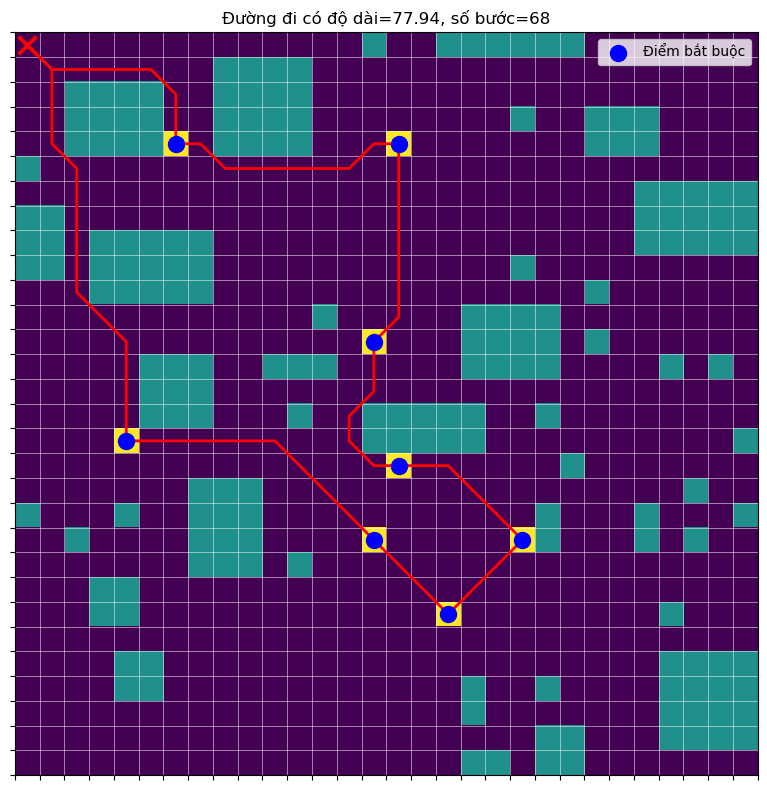

In [17]:
visualize_path(grid, path, mandatory_waypoints)